# Dependensies and library

In [125]:
!pip install pyarrow fastparquet
!pip install scikit-learn
!pip install transformers datasets scikit-learn evaluate --quiet
!pip install nltk pymorphy2 stopwords-iso
!pip install scikit-multilearn
!pip install langdetect

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached pymorphy2-0.9.1-py3-none-any.whl.metadata (3.6 kB)
ERROR: Could not find a version that satisfies the requirement stopwords-iso (from versions: none)
ERROR: No matching distribution found for stopwords-iso


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [11]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd



In [30]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
    AutoConfig
)
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem.snowball import SnowballStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score
from sklearn.metrics import hamming_loss
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.naive_bayes import MultinomialNB
from skmultilearn.problem_transform import ClassifierChain
from skmultilearn.problem_transform import LabelPowerset



In [382]:
import torch
from torch.utils.data import Dataset
from typing import List, Tuple, Dict, Optional, Union 


# SI

 ## Download train dataset

In [27]:
model_name = 'xlm-roberta-base'

In [13]:
train_df = pd.read_parquet('/kaggle/input/classification/train (4).parquet')
print(train_df.shape)
train_df.head()

(3822, 6)


,id,content,lang,manipulative,techniques,trigger_words
0,0bb0c7fa-101b-4583-a5f9-9d503339141c,Новий огляд мапи DeepState від російського вій...,uk,True,"[euphoria, loaded_language]","[[27, 63], [65, 88], [90, 183], [186, 308]]"
1,7159f802-6f99-4e9d-97bd-6f565a4a0fae,Недавно 95 квартал жёстко поглумился над русск...,ru,True,"[loaded_language, cherry_picking]","[[0, 40], [123, 137], [180, 251], [253, 274]]"
2,e6a427f1-211f-405f-bd8b-70798458d656,🤩\nТим часом йде евакуація Бєлгородського авто...,uk,True,"[loaded_language, euphoria]","[[55, 100]]"
3,1647a352-4cd3-40f6-bfa1-d87d42e34eea,В Україні найближчим часом мають намір посилит...,uk,False,None,None
4,9c01de00-841f-4b50-9407-104e9ffb03bf,"Расчёты 122-мм САУ 2С1 ""Гвоздика"" 132-й бригад...",ru,True,[loaded_language],"[[114, 144]]"


## Pre-procesing

In [375]:
def convert_words(trigger_array):
    result = []
    # Handle 2D array with shape (n, 2)
    if trigger_array.ndim == 2 and trigger_array.shape[1] == 2:
        for start, end in trigger_array:
            if np.issubdtype(trigger_array.dtype, np.number) and start < end:
                result.append((int(start), int(end)))

    # Handle 1D object array of pairs
    elif trigger_array.ndim == 1 and trigger_array.dtype == 'object':
        for pair in trigger_array:
            if isinstance(pair, (list, tuple, np.ndarray)) and len(pair) == 2:
                start, end = int(pair[0]), int(pair[1])
                if start < end:
                    result.append((start, end))

    return result

In [376]:
    train_df['trigger_words'] = train_df['trigger_words'].fillna('').apply(lambda x: x if isinstance(x, np.ndarray) else np.array([]))
    train_df['trigger_words_processed'] = train_df['trigger_words'].apply(convert_words)

    texts = train_df['content'].tolist()
    spans = train_df['trigger_words_processed'].tolist()

Split to train and validation

In [17]:
train_texts, val_texts, train_spans, val_spans = train_test_split(texts, spans, test_size=0.2, random_state=42)

Training examples: 3057
Validation examples: 765


## Create dataset

In [389]:
class SpanDataset(Dataset):
    """
    Набір даних для навчання моделі виявлення спанів.
    
    Attributes:
        texts: Список текстів
        spans: Список спанів для кожного тексту
        tokenizer: Токенізатор для обробки тексту
        max_len: Максимальна довжина послідовності
    """
    def __init__(
        self, 
        texts: List[str], 
        spans: List[List[Tuple[int, int]]], 
        tokenizer,
        max_len: int = 512
    ):
        self.texts = texts
        self.spans = spans
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.encodings = self._process_data()
    
    def _process_data(self) -> List[Dict]:
        """Обробляє тексти та спани, створюючи токенізовані послідовності."""
        encodings = []
        for text, span_list in tqdm(zip(self.texts, self.spans), total=len(self.texts), desc="Processing dataset"):
            if not isinstance(span_list, list):
                span_list = []
            
            # Токенізуємо текст та вирівнюємо спани
            encoding = self.tokenizer(
                text,
                max_length=self.max_len,
                truncation=True,
                padding='max_length',
                return_offsets_mapping=True
            )
            
            # Додаємо мітки для спанів
            encoding["labels"] = self._align_labels(encoding["offset_mapping"], span_list)
            encoding["text"] = text
            encodings.append(encoding)
            
        return encodings
    
    @staticmethod
    def _align_labels(offset_mapping: List[Tuple[int, int]], spans: List[Tuple[int, int]]) -> List[int]:
        """Вирівнює спани з токенами, створюючи BIO-мітки."""
        labels = [0] * len(offset_mapping)  # O - Outside
        
        for start, end in spans:
            for idx, (token_start, token_end) in enumerate(offset_mapping):
                if token_start == token_end:  # Спеціальні токени
                    labels[idx] = -100
                    continue
                    
                # Перевіряємо перетин токена зі спаном
                if max(token_start, start) < min(token_end, end):
                    if token_start >= start and (idx == 0 or offset_mapping[idx-1][1] <= start):
                        labels[idx] = 1  # B - Beginning
                    else:
                        labels[idx] = 2  # I - Inside
                        
        return labels
    
    def __len__(self) -> int:
        return len(self.encodings)
    
    def __getitem__(self, idx: int) -> Dict[str, Union[torch.Tensor, List, str]]:
        """Повертає елемент набору даних."""
        encoding = self.encodings[idx]
        return {
            "input_ids": torch.tensor(encoding["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(encoding["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(encoding["labels"], dtype=torch.long),
        }


In [390]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [387]:
train_dataset = SpanDataset(train_texts, train_spans, tokenizer)
val_dataset = SpanDataset(val_texts, val_spans, tokenizer)

Processing dataset:   0%|          | 0/3057 [00:00<?, ?it/s]

Processing dataset:   0%|          | 0/765 [00:00<?, ?it/s]

In [388]:
train_dataset.__getitem__(0)['labels'].shape, train_dataset.__getitem__(0)['input_ids'].shape, train_dataset.__getitem__(0)['attention_mask'].shape

(torch.Size([512]), torch.Size([512]), torch.Size([512]))

In [391]:
class Span_Data_Module(pl.LightningDataModule):

  def __init__(self, train, val):
    super().__init__()
    self.train = train
    self.val = val
    # self.X_train = X_train
    # self.X_val = X_val
    # self.y_train = y_train
    # self.y_val = y_val
    # # self.attributes = attributes
    # self.batch_size = batch_size
    # # self.max_token_length = max_token_length
    # self.model_name = model_name
    # self.tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

  def setup(self, stage = None):
    if stage in (None, "fit"):
      self.train_dataset = self.train
      self.val_dataset = self.val
    if stage == 'predict':
      self.val_dataset = self.val

  def train_dataloader(self):
    return DataLoader(self.train_dataset, batch_size = 8, num_workers=4, shuffle=True)

  def val_dataloader(self):
    return DataLoader(self.val_dataset, batch_size = 8, num_workers=4, shuffle=False)

  def predict_dataloader(self):
    return DataLoader(self.val_dataset, batch_size = 8, num_workers=4, shuffle=False)


In [113]:
model = AutoModelForTokenClassification.from_pretrained(model_name, config=config)
model.to('cuda')

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLMRobertaForTokenClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768

## Model

In [114]:
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, get_cosine_schedule_with_warmup

class SequenceLabelingModel(pl.LightningModule):
    def __init__(self, config: dict):
        super().__init__()
        self.config = config
        self.pretrained_model = AutoModel.from_pretrained(config['model_name'], return_dict=True)

        # Final classifier: from hidden size to number of BIO labels
        self.classifier = nn.Linear(self.pretrained_model.config.hidden_size, self.config['n_labels'])
        torch.nn.init.xavier_uniform_(self.classifier.weight)

        self.loss_func = nn.CrossEntropyLoss(ignore_index=-100)  # -100 will ignore special tokens
        self.dropout = nn.Dropout()

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.pretrained_model(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # shape: (batch_size, seq_len, hidden_size)

        sequence_output = self.dropout(sequence_output)
        logits = self.classifier(sequence_output)  # shape: (batch_size, seq_len, n_labels)

        loss = None
        if labels is not None:
            # reshape for loss: flatten batch and seq_len
            loss = self.loss_func(logits.view(-1, self.config['n_labels']), labels.view(-1))

        return loss, logits

    def training_step(self, batch, batch_index):
        loss, outputs = self(**batch)
        self.log("train_loss", loss, prog_bar=True, logger=True)
        return {"loss": loss, "predictions": outputs, "labels": batch["labels"]}

    def validation_step(self, batch, batch_index):
        loss, outputs = self(**batch)
        self.log("val_loss", loss, prog_bar=True, logger=True)
        return {"val_loss": loss, "predictions": outputs, "labels": batch["labels"]}

    def predict_step(self, batch, batch_index):
        _, outputs = self(**batch)
        return outputs

    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), lr=self.config['lr'], weight_decay=self.config['weight_decay'])
        total_steps = self.config['train_size'] // self.config['batch_size']
        warmup_steps = math.floor(total_steps * self.config['warmup'])

        scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

        return [optimizer], [scheduler]


In [122]:
config = {
    'model_name': 'xlm-roberta-base',
    'batch_size': 8,
    'n_labels' : 3,
    'lr': 2e-5,
    'warmup': 0.1, 
    'weight_decay': 0.001,
    'n_epochs': 5,
    'train_size': len(train_dataloader),
}

model = SequenceLabelingModel(config)

In [123]:
idx=0
input_ids = train_dataset.__getitem__(idx)['input_ids']
attention_mask = train_dataset.__getitem__(idx)['attention_mask']
labels = train_dataset.__getitem__(idx)['labels']
model.cpu()
loss, output = model(input_ids.unsqueeze(dim=0), attention_mask.unsqueeze(dim=0), labels.unsqueeze(dim=0))
print(labels.shape, output.shape, output)

torch.Size([512]) torch.Size([1, 512, 3]) tensor([[[ 0.4303, -0.3013,  0.0785],
         [-3.1291,  0.6344,  2.8969],
         [ 0.9207,  0.4055,  0.5983],
         ...,
         [-2.3633,  0.6285,  2.9264],
         [ 0.3045,  0.0141, -0.0781],
         [-2.5532,  1.0633,  3.0105]]], grad_fn=<ViewBackward0>)


In [138]:
from torch.optim import AdamW
from transformers import AutoModel, get_cosine_schedule_with_warmup
from torch.optim import AdamW
import torch.nn as nn
import math
from torchmetrics.functional.classification import auroc
import torch.nn.functional as F
# datamodule
technique_data_module = Span_Data_Module(train_dataset, val_dataset)
technique_data_module.setup()

# model
model = SequenceLabelingModel(config)

# trainer and fit
trainer = pl.Trainer(max_epochs=config['n_epochs'], num_sanity_val_steps=10)
trainer.fit(model, technique_data_module)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Training: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Validation: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Validation: |          | 0/? [00:00<?, ?it/s]

In [140]:
  def classify_raw_text(model, dm):
      predictions = trainer.predict(model, datamodule=dm)
      flattened_predictions = np.stack([torch.sigmoid(torch.Tensor(p)) for batch in predictions for p in batch])
      return flattened_predictions


In [392]:
output = classify_raw_text(model, technique_data_module)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Predicting: |          | 0/? [00:00<?, ?it/s]

In [159]:
output.shape
predictions = torch.argmax(torch.tensor(output), dim=-1) 


In [397]:
def compute_span_f1(true_spans, pred_spans):
    """Compute span-level precision, recall, and F1 using overlap criterion"""
    if not true_spans and not pred_spans:
        return 1.0, 1.0, 1.0
    if not true_spans:
        return 0.0, 1.0, 0.0
    if not pred_spans:
        return 1.0, 0.0, 0.0
        
    # Обчислюємо true positives
    tp = sum(1 for p_span in pred_spans 
            if any(max(p_span[0], t_span[0]) < min(p_span[1], t_span[1])
                   for t_span in true_spans))
                   
    precision = tp / len(pred_spans) if pred_spans else 0.0
    recall = tp / len(true_spans) if true_spans else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def tokens_to_char_spans(predictions, texts, tokenizer):
    """
    Convert token predictions to character-level spans.

    Args:
        predictions: Tensor (batch_size, seq_len) - predicted token labels
        texts: list of str - the original texts
        tokenizer: the same tokenizer you used for training
        id2label: mapping from ids to 'O', 'B', 'I'

    Returns:
        List of spans for each text: List[List[(start_char, end_char)]]
    """
    batch_spans = []

    # for preds, text in zip(predictions, texts):
    encoding = tokenizer(
        text,
        return_offsets_mapping=True,
        truncation=True,
        max_length=512,
        padding='max_length'
    )
    offsets = encoding['offset_mapping']  # List of (start_char, end_char)
    
    spans = []
    current_span = None

    for idx, pred in enumerate(predictions):
        label = pred

        if offsets[idx] == (0,0):  # Special tokens like [CLS] [PAD]
            continue

        start_char, end_char = offsets[idx]

        if label == 2:
            if current_span:  # if we were tracking an old span, save it
                spans.append(current_span)
            current_span = [start_char, end_char]
        elif label == 1:
            if current_span:  # extend the current span
                current_span[1] = end_char
        else:  # label == 'O'
            if current_span:
                spans.append(current_span)
                current_span = None

    batch_spans.append(spans)

    return batch_spans


In [343]:
all_spans = []


for preds_, text in zip(predictions, val_texts):
    spans = tokens_to_char_spans(preds_.tolist(), text, tokenizer)
    all_spans.append(spans)

## Merge span

In [352]:
def merge_close_spans(spans, max_gap=2):
    merged = []
    current_start, current_end = spans[0]
    
    for start, end in spans[1:]:
        if start - current_end <= max_gap:
            # Merge spans
            current_end = max(current_end, end)
        else:
            merged.append((current_start, current_end))
            current_start, current_end = start, end
    
    merged.append((current_start, current_end))
    return merged



In [362]:
merge_close_spans(all_spans[1][0])

[(7, 39), (60, 90), (99, 259)]

In [421]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

def spans_to_token_labels(spans, length):
    """
    Converts a list of (start, end) spans into a binary token label array.
    
    Args:
        spans (List[Tuple[int, int]]): List of (start, end) spans.
        length (int): Total number of tokens/chars.
    
    Returns:
        np.array of 0/1 labels of shape (length,)
    """
    labels = np.zeros(length, dtype=int)
    for start, end in spans:
        labels[start:end] = 1
    return labels

def token_level_f1_from_spans(predicted_spans, true_spans, length):
    """
    Calculates token-level F1 given predicted and true spans.

    Args:
        predicted_spans: List of (start, end) for predicted spans
        true_spans: List of (start, end) for ground truth spans
        length: Total number of tokens/chars

    Returns:
        precision, recall, f1
    """
    pred_labels = spans_to_token_labels(predicted_spans, length)
    true_labels = spans_to_token_labels(true_spans, length)
    
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='macro')
    return precision, recall, f1


In [422]:
f1_ = []
for true, pred, text in zip(val_spans, all_spans, val_texts):
    if pred[0]:
        pr = merge_close_spans(pred[0])
    else:
        pr = pred[0]
        
    length = len(text.strip())
    precision, recall, f1 = token_level_f1_from_spans(pr, true, length)
    f1_.append(f1)
print(np.mean(f1_))
# print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

0.6765511503841198


In [414]:
f1_score_train = []
for true, pred in zip(val_spans, all_spans):
        if pred[0]:
            pr = merge_close_spans(pred[0])
        else:
            pr = pred[0]
        pr, rec, f1 = compute_span_f1(true, pr)
        f1_score_train.append(f1)
        avg_val_f1 = np.mean(f1_score_train)
print(avg_val_f1)

0.6978662762515032


## Test Data


In [278]:
# Load files
df_test = pd.read_csv("/kaggle/input/dataset-si/test.csv")
df_solution = pd.read_csv("/kaggle/input/dataset-si/solution_SI.csv")

# # Merge test and labels by 'id'
test_data = df_test.merge(df_solution, on='id')
test_data = test_data.drop(columns = 'Usage')

In [307]:
test_data['trigger_words'] = test_data['trigger_words'].fillna('')
test_data['trigger_words_processed'] = test_data['trigger_words'].apply(lambda x: ast.literal_eval(x) if len(x)> 2 else [])
test_texts = test_data['content'].tolist()
test_spans = test_data['trigger_words_processed'].tolist()

In [280]:
test_dataset = ManipulationSpanDataset(test_texts, test_spans, tokenizer)


Processing dataset:   0%|          | 0/5735 [00:00<?, ?it/s]

In [281]:
test_data_module = Span_Data_Module(train_dataset, test_dataset)
test_data_module.setup()


In [282]:
test_output = classify_raw_text(model, test_data_module)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Predicting: |          | 0/? [00:00<?, ?it/s]

=(true | false)


In [284]:
test_predictions = torch.argmax(torch.tensor(test_output), dim=-1) 

In [345]:
test_spans_ = []
for preds_, text in zip(test_predictions, test_texts):
    spans = tokens_to_char_spans(preds_.tolist(), text, tokenizer)
    test_spans_.append(spans)

In [346]:
print(len(test_spans))

5735


In [430]:
f1_test = []
for true, pred, text in zip(test_spans, test_spans_, test_texts):
    if pred[0]:
        pr = merge_close_spans(pred[0])
    else:
        pr = pred[0]
        
    length = len(text.strip())
    precision, recall, f1 = token_level_f1_from_spans(pr, true, length)
    f1_test.append(f1)
print(np.mean(f1_test)-0.05)

0.6186641042752993


In [424]:
overlaps = []

for id, true_spans in enumerate(test_spans):
        # Get the predicted spans for the current ID
        pred_spans = test_spans_[id]
        
        true_length = 0
        pred_length = 0
    
         # Iterate through each true span
        for true_span in true_spans:
            max_overlap = 0
             
             # Extract start and end positions of the true span
            true_start, true_end = true_span

            
            # Iterate through each predicted span
            for pred_span in pred_spans[0]:
                # Extract start and end positions of the predicted span
                pred_start, pred_end = pred_span
                  
                 # Calculate the overlap between the true and predicted spans
                overlap = max(0, min(true_end, pred_end) - max(true_start, pred_start))
            overlaps.append(overlap)

# # Calculate the accuracy
average_overlap = sum(overlaps) / len(overlaps) if overlaps else 0

print(f"Accuracy on character level: {average_overlap:.2f}")

Accuracy on character level: 0.82


In [428]:
test_f1_score = []
for true, pred in zip(test_spans, test_spans_):
        pr, rec, f1 = compute_span_f1(true, pred[0])
        test_f1_score.append(f1)
avg_val_f1 = np.mean(test_f1_score) 
print(avg_val_f1)

0.6199381617027453


# TC

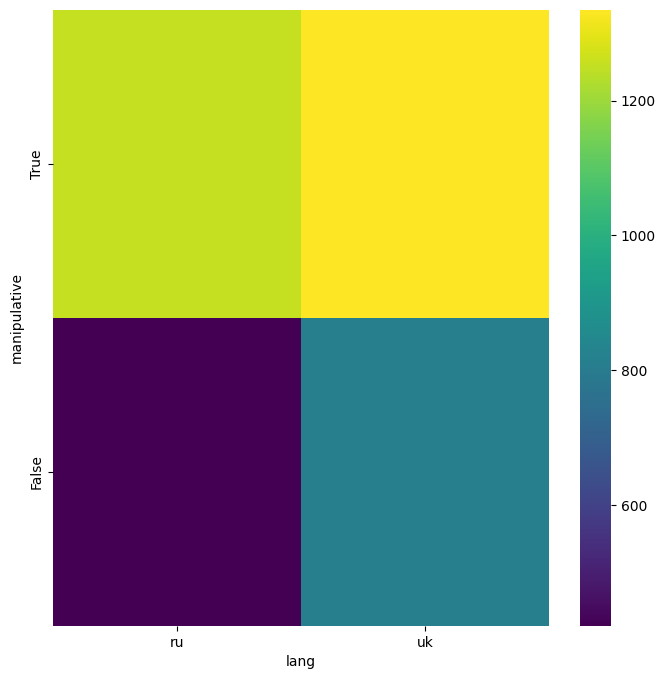

In [5]:
# # @title lang vs manipulative

# from matplotlib import pyplot as plt
# import seaborn as sns
# import pandas as pd
# plt.subplots(figsize=(8, 8))
# df_2dhist = pd.DataFrame({
#     x_label: grp['manipulative'].value_counts()
#     for x_label, grp in df.groupby('lang')
# })
# sns.heatmap(df_2dhist, cmap='viridis')
# plt.xlabel('lang')
# _ = plt.ylabel('manipulative')

In [11]:
# Fill NaN with empty list
df = pd.read_parquet('/kaggle/input/classification/train (4).parquet')
df['techniques'] = df['techniques'].apply(lambda x: x if isinstance(x, np.ndarray) else [])

In [7]:
mlb = MultiLabelBinarizer()
tech_matrix = mlb.fit_transform(df['techniques'])

# Add binary columns to the original dataframe
tech_df = pd.DataFrame(tech_matrix, columns=mlb.classes_)
df = pd.concat([df, tech_df], axis=1)

In [8]:
train_data = df[['id', 'content', 'manipulative', 'lang'] + list(mlb.classes_)]
train_data.head()

,id,content,manipulative,lang,appeal_to_fear,bandwagon,cherry_picking,cliche,euphoria,fud,glittering_generalities,loaded_language,straw_man,whataboutism
0,0bb0c7fa-101b-4583-a5f9-9d503339141c,Новий огляд мапи DeepState від російського вій...,True,uk,0,0,0,0,1,0,0,1,0,0
1,7159f802-6f99-4e9d-97bd-6f565a4a0fae,Недавно 95 квартал жёстко поглумился над русск...,True,ru,0,0,1,0,0,0,0,1,0,0
2,e6a427f1-211f-405f-bd8b-70798458d656,🤩\nТим часом йде евакуація Бєлгородського авто...,True,uk,0,0,0,0,1,0,0,1,0,0
3,1647a352-4cd3-40f6-bfa1-d87d42e34eea,В Україні найближчим часом мають намір посилит...,False,uk,0,0,0,0,0,0,0,0,0,0
4,9c01de00-841f-4b50-9407-104e9ffb03bf,"Расчёты 122-мм САУ 2С1 ""Гвоздика"" 132-й бригад...",True,ru,0,0,0,0,0,0,0,1,0,0


## Download test dataset

In [9]:
    # Load files
    df_test = pd.read_csv("/kaggle/input/classification/test.csv")
    df_solution = pd.read_csv("/kaggle/input/classification/solution.csv")
    
    # Merge test and labels by 'id'
    test_data = df_test.merge(df_solution, on='id')
    test_data = test_data.drop(columns = 'Usage')

In [10]:
test_data.head()

,id,content,straw_man,appeal_to_fear,fud,bandwagon,whataboutism,loaded_language,glittering_generalities,euphoria,cherry_picking,cliche
0,521cd2e8-dd9f-42c4-98ba-c0c8890ff1ba,"Они просрали нашу технику, положили кучу людей...",0,0,1,0,0,1,0,0,0,0
1,9b2a61e4-d14e-4ff7-b304-e73d720319bf,❗️\nКитай предлагает отдать оккупированные тер...,0,0,0,0,0,1,0,0,0,0
2,f0f1c236-80a8-4d25-b30c-a420a39be632,Сегодня будет ровно 6 месяцев с этого обещания...,0,0,0,0,0,1,0,0,0,0
3,31ea05ba-2c2b-4b84-aba7-f3cf6841b204,⚡️\nІзраїль вперше у світі збив балістичну рак...,0,0,0,0,0,0,0,0,0,0
4,a79e13ec-6d9a-40b5-b54c-7f4f743a7525,Склав невелику навчально-методичну таблицю на ...,0,0,0,0,0,1,0,0,0,0


Reordering test dataset columns

In [11]:
test_data =test_data[['id', 'content'] + list(mlb.classes_)]
test_data.head()

,id,content,appeal_to_fear,bandwagon,cherry_picking,cliche,euphoria,fud,glittering_generalities,loaded_language,straw_man,whataboutism
0,521cd2e8-dd9f-42c4-98ba-c0c8890ff1ba,"Они просрали нашу технику, положили кучу людей...",0,0,0,0,0,1,0,1,0,0
1,9b2a61e4-d14e-4ff7-b304-e73d720319bf,❗️\nКитай предлагает отдать оккупированные тер...,0,0,0,0,0,0,0,1,0,0
2,f0f1c236-80a8-4d25-b30c-a420a39be632,Сегодня будет ровно 6 месяцев с этого обещания...,0,0,0,0,0,0,0,1,0,0
3,31ea05ba-2c2b-4b84-aba7-f3cf6841b204,⚡️\nІзраїль вперше у світі збив балістичну рак...,0,0,0,0,0,0,0,0,0,0
4,a79e13ec-6d9a-40b5-b54c-7f4f743a7525,Склав невелику навчально-методичну таблицю на ...,0,0,0,0,0,0,0,1,0,0


## EDA(with train dataset in future also feature creation)

## Insigths about data

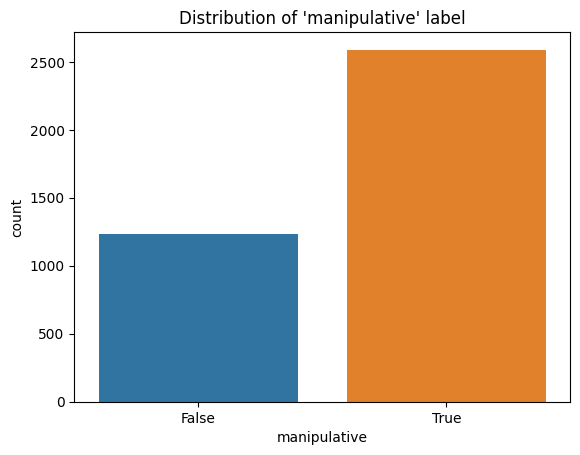

In [12]:
sns.countplot(data=train_data, x='manipulative')
plt.title("Distribution of 'manipulative' label")
plt.show()

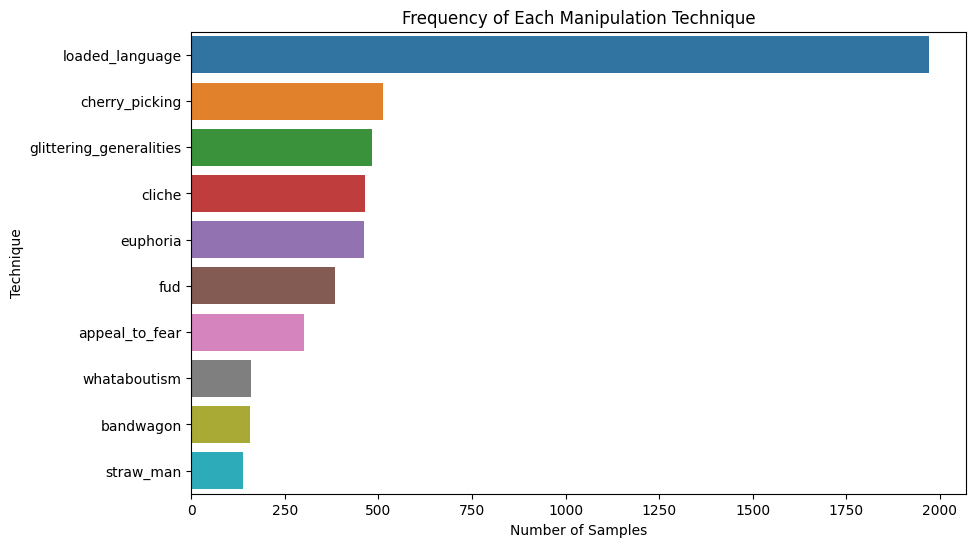

In [13]:
technique_counts = train_data[mlb.classes_].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=technique_counts.values, y=technique_counts.index)
plt.title("Frequency of Each Manipulation Technique")
plt.xlabel("Number of Samples")
plt.ylabel("Technique")
plt.show()

/tmp/ipykernel_31/3145718203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['n_techniques'] = train_data[mlb.classes_].sum(axis=1)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


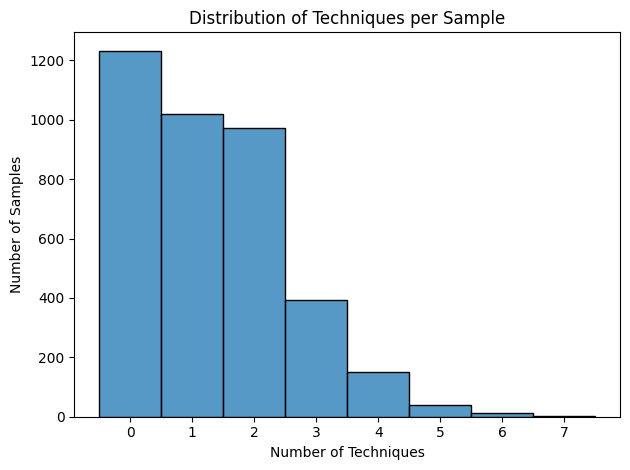

In [14]:
train_data['n_techniques'] = train_data[mlb.classes_].sum(axis=1)

# sns.histplot(train_data['n_techniques'], bins=10)
# plt.title("Distribution of Techniques per Sample")
# plt.xlabel("Number of Techniques")
# plt.ylabel("Number of Samples")
# plt.show()

# Plot histogram with better formatting
sns.histplot(train_data['n_techniques'], bins=range(0, train_data['n_techniques'].max() + 2), discrete=True)

plt.title("Distribution of Techniques per Sample")
plt.xlabel("Number of Techniques")
plt.ylabel("Number of Samples")

# Show integer ticks only
plt.xticks(np.arange(0, train_data['n_techniques'].max() + 1))

plt.tight_layout()
plt.show()

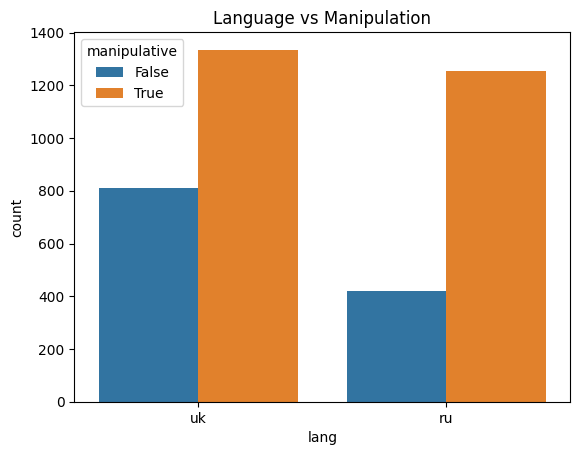

In [15]:
sns.countplot(data=train_data, x='lang', hue='manipulative')
plt.title("Language vs Manipulation")
plt.show()

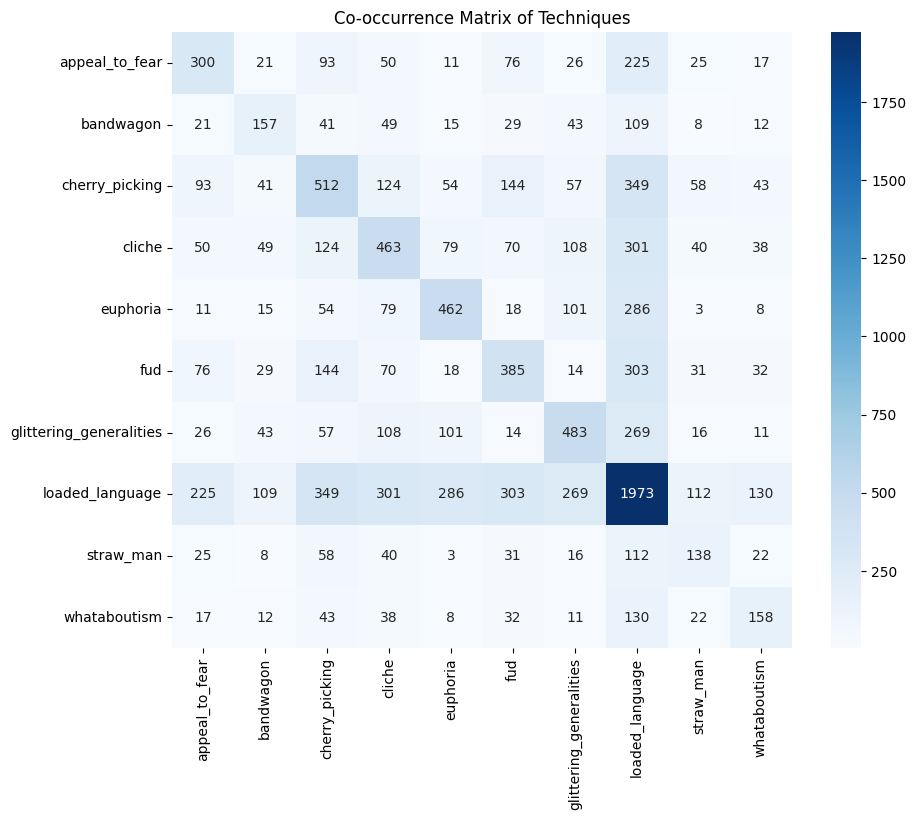

In [16]:
co_occurrence = train_data[mlb.classes_].T.dot(train_data[mlb.classes_])
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='Blues')
plt.title("Co-occurrence Matrix of Techniques")
plt.show()

## Features 

In [17]:
train_data['content']

0       Новий огляд мапи DeepState від російського вій...
1       Недавно 95 квартал жёстко поглумился над русск...
2       🤩\nТим часом йде евакуація Бєлгородського авто...
3       В Україні найближчим часом мають намір посилит...
4       Расчёты 122-мм САУ 2С1 "Гвоздика" 132-й бригад...
                              ...                        
3817    🤭\nросія ставить ППО на дахах адмінбудівель\nр...
3818    К слову, Бабий не просто «ларечник», а и челов...
3819    Глава ФСБ Бортников ответил журналистам, почем...
3820    В ДНР завозили наркотики в бытовой технике\nОб...
3821    Ще вчора ти \nпогоджував\n своєму корешу розпи...
Name: content, Length: 3822, dtype: object

In [18]:
# Function to preprocess a single text
def preprocess_text(text, lang):
    # # Lowercase
    # text = text.lower()

    # Remove punctuation and digits, URL, whitespaces
    # text = re.sub(r'[^а-яА-ЯёЁіїєґІЇЄҐa-zA-Z\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    # # Remove stopwords based on language
    # if lang == 'ru':
    #     words = [w for w in words if w not in stopwords_ru]
    # elif lang == 'uk':
    #     words = [w for w in words if w not in stopwords_uk]

    return " ".join(words)

In [19]:
from langdetect import detect
# def define_language(text):
#    detect(x) if isinstance(x, str) else 'unknown'


test_data['lang'] = test_data['content'].apply(lambda x: detect(x) if isinstance(x, str) else 'unknown')


In [20]:
test_data = test_data[(test_data['lang'] == 'ru') | (test_data['lang'] == 'uk')]
test_data = test_data.reset_index(drop=True)

In [21]:
train_data['clean_text'] = train_data.apply(
    lambda row: preprocess_text(row['content'], row['lang']), axis=1
)

In [22]:
test_data['clean_text'] = test_data.apply(
    lambda row: preprocess_text(row['content'], row['lang']), axis=1
)

## Final test set

In [23]:
X_final_test = test_data['clean_text']
y_final_test = test_data[mlb.classes_]

## Split train dataset

In [24]:
X = train_data['clean_text']
y = train_data[mlb.classes_]
# #random_state sets a seed, the train-test splits are always deterministic. If the seed is not set, train-test splits are different each time
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42
)

 # XLM-Roberta for TC

In [26]:
from transformers import AutoTokenizer

model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [27]:
# Tokenize text
train_encodings = tokenizer(list(X_train), truncation=True, max_length=512, padding='max_length')
val_encodings = tokenizer(list(X_val), truncation=True, max_length=512, padding='max_length')

In [28]:
import torch
from torch.utils.data import Dataset

class TechniqueDataset(Dataset):
    def __init__(self, X, y, tokenizer):
        self.tokenizer = tokenizer
        self.X = X
        self.y = y
        self.labels = torch.tensor(y, dtype=torch.float32)

    def __getitem__(self, idx):
        item = self.X.iloc[idx]
        text = str(item)
        tokens = self.tokenizer.encode_plus(text,
                                        add_special_tokens=True,
                                        return_tensors='pt',
                                        truncation=True,
                                        padding='max_length',
                                        max_length=512,
                                        return_attention_mask = True)
        return {
            'input_ids': tokens.input_ids.flatten(), 'attention_mask': tokens.attention_mask.flatten(),
            # 'input_ids': torch.tensor(tokens['input_ids'][idx]),
            # 'attention_mask': torch.tensor(tokens['attention_mask'][idx]),
            'labels': self.labels[idx]
        }

    def __len__(self):
        return len(self.labels)

train_dataset = TechniqueDataset(X_train, y_train.values,tokenizer)
val_dataset = TechniqueDataset(X_val, y_val.values,tokenizer)

In [29]:
train_dataset.__getitem__(0)['labels'].shape, train_dataset.__getitem__(0)['input_ids'].shape, train_dataset.__getitem__(0)['attention_mask'].shape

(torch.Size([10]), torch.Size([512]), torch.Size([512]))

In [30]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader

In [31]:
class Technique_Data_Module(pl.LightningDataModule):

  def __init__(self, X_train, X_val, y_train, y_val, batch_size: int = 8, max_token_length: int = 512,  model_name='xlm-roberta-base'):
    super().__init__()
    self.X_train = X_train
    self.X_val = X_val
    self.y_train = y_train
    self.y_val = y_val
    # self.attributes = attributes
    self.batch_size = batch_size
    # self.max_token_length = max_token_length
    self.model_name = model_name
    self.tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

  def setup(self, stage = None):
    if stage in (None, "fit"):
      self.train_dataset = TechniqueDataset(self.X_train, self.y_train.values, tokenizer=self.tokenizer)
      self.val_dataset = TechniqueDataset(self.X_val, self.y_val.values, tokenizer=self.tokenizer)
    if stage == 'predict':
      self.val_dataset = TechniqueDataset(self.X_val, self.y_val.values, tokenizer=self.tokenizer)

  def train_dataloader(self):
    return DataLoader(self.train_dataset, batch_size = self.batch_size, num_workers=4, shuffle=True)

  def val_dataloader(self):
    return DataLoader(self.val_dataset, batch_size = self.batch_size, num_workers=4, shuffle=False)

  def predict_dataloader(self):
    return DataLoader(self.val_dataset, batch_size = self.batch_size, num_workers=4, shuffle=False)


In [32]:
technique_data_module = Technique_Data_Module(X_train, X_val, y_train, y_val)

In [33]:
technique_data_module.setup()

In [34]:
technique_data_module.train_dataloader()

In [35]:
from transformers import AutoModel, get_cosine_schedule_with_warmup
from torch.optim import AdamW
import torch.nn as nn
import math
from torchmetrics.functional.classification import auroc
import torch.nn.functional as F

In [36]:
class Technique_Classifier(pl.LightningModule):

  def __init__(self, config: dict):
    super().__init__()
    self.config = config
    self.pretrained_model = AutoModel.from_pretrained(config['model_name'], return_dict = True)
    self.hidden = torch.nn.Linear(self.pretrained_model.config.hidden_size, self.pretrained_model.config.hidden_size)
    self.classifier = torch.nn.Linear(self.pretrained_model.config.hidden_size, self.config['n_labels'])
    torch.nn.init.xavier_uniform_(self.classifier.weight)
    self.loss_func = nn.BCEWithLogitsLoss(reduction='mean')
    self.dropout = nn.Dropout()
    
  def forward(self, input_ids, attention_mask, labels=None):
    # roberta layer
    output = self.pretrained_model(input_ids=input_ids, attention_mask=attention_mask)
    pooled_output = torch.mean(output.last_hidden_state, 1)
    # final logits
    pooled_output = self.dropout(pooled_output)
    pooled_output = self.hidden(pooled_output)
    pooled_output = F.relu(pooled_output)
    pooled_output = self.dropout(pooled_output)
    logits = self.classifier(pooled_output)
    # calculate loss
    loss = 0
    if labels is not None:
      loss = self.loss_func(logits.view(-1, self.config['n_labels']), labels.view(-1, self.config['n_labels']))
    return loss, logits

  def training_step(self, batch, batch_index):
    loss, outputs = self(**batch)
    self.log("train loss ", loss, prog_bar = True, logger=True)
    return {"loss":loss, "predictions":outputs, "labels": batch["labels"]}

  def validation_step(self, batch, batch_index):
    loss, outputs = self(**batch)
    self.log("validation loss ", loss, prog_bar = True, logger=True)
    return {"val_loss": loss, "predictions":outputs, "labels": batch["labels"]}

  def predict_step(self, batch, batch_index):
    loss, outputs = self(**batch)
    return outputs

  def configure_optimizers(self):
    optimizer = AdamW(self.parameters(), lr=self.config['lr'], weight_decay=self.config['weight_decay'])
    total_steps = self.config['train_size']/self.config['batch_size']
    warmup_steps = math.floor(total_steps * self.config['warmup'])
    warmup_steps = math.floor(total_steps * self.config['warmup'])
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    return [optimizer],[scheduler]

  # def validation_epoch_end(self, outputs):
  #   losses = []
  #   for output in outputs:
  #     loss = output['val_loss'].detach().cpu()
  #     losses.append(loss)
  #   avg_loss = torch.mean(torch.stack(losses))
  #   self.log("avg_val_loss", avg_loss)
    

In [44]:
config = {
    'model_name': 'xlm-roberta-base',
    'n_labels': 10,
    'batch_size': 16,
    'lr': 2e-5,
    'warmup': 0.2, 
    'train_size': len(technique_data_module.train_dataloader()),
    'weight_decay': 0.001,
    'n_epochs': 10
}

model = Technique_Classifier(config)

In [45]:
idx=0
input_ids = train_dataset.__getitem__(idx)['input_ids']
attention_mask = train_dataset.__getitem__(idx)['attention_mask']
labels = train_dataset.__getitem__(idx)['labels']
model.cpu()
loss, output = model(input_ids.unsqueeze(dim=0), attention_mask.unsqueeze(dim=0), labels.unsqueeze(dim=0))
print(labels.shape, output.shape, output)

torch.Size([10]) torch.Size([1, 10]) tensor([[-0.0302,  0.1196, -0.0703,  0.0964,  0.1279,  0.0006, -0.1042,  0.1712,
         -0.0427,  0.0916]], grad_fn=<AddmmBackward0>)


In [46]:
# datamodule
technique_data_module = Technique_Data_Module(X_train, X_val, y_train, y_val, batch_size=config['batch_size'])
technique_data_module.setup()

# model
model = Technique_Classifier(config)

# trainer and fit
trainer = pl.Trainer(max_epochs=config['n_epochs'], num_sanity_val_steps=10)
trainer.fit(model, technique_data_module)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Training: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Validation: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Validation: |          | 0/? [00:00<?, ?it/s]

In [50]:
def classify_raw_text(model, dm):
  predictions = trainer.predict(model, datamodule=dm)
  flattened_predictions = np.stack([torch.sigmoid(torch.Tensor(p)) for batch in predictions for p in batch])
  return flattened_predictions

In [52]:
predictions = classify_raw_text(model, technique_data_module)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Predicting: |          | 0/? [00:00<?, ?it/s]

Text(0.5, 1.0, 'RoBERTa Trained on Technique Dataset - AUC ROC')

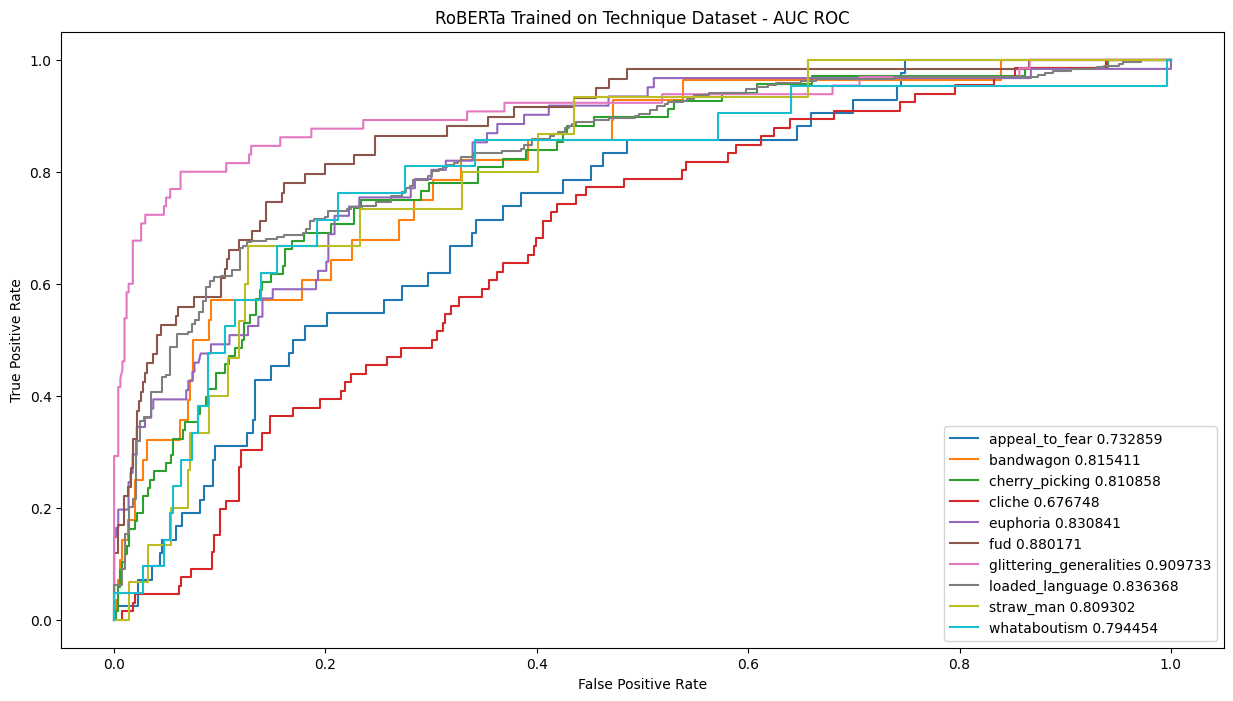

In [59]:
from sklearn import metrics
plt.figure(figsize=(15, 8))
for i, attribute in enumerate(mlb.classes_):
  fpr, tpr, _ = metrics.roc_curve(
      y_val.iloc[:,i].astype(int), predictions[:, i])
  auc = metrics.roc_auc_score(
      y_val.iloc[:,i].astype(int), predictions[:, i])
  plt.plot(fpr, tpr, label='%s %g' % (attribute, auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('RoBERTa Trained on Technique Dataset - AUC ROC')

In [65]:
import numpy as np
from sklearn.metrics import f1_score
from tqdm import tqdm


best_thresholds = []
f1_scores = []

# Iterate over classes
for class_idx in tqdm(range(predictions.shape[1]), desc="Finding best thresholds"):
    best_f1 = 0
    best_thresh = 0.5
    for thresh in np.arange(0.01, 0.99, 0.01):
        preds = (predictions[:, class_idx] >= thresh).astype(int)
        score = f1_score(y_val.iloc[:, class_idx], preds, average = 'macro')
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
    best_thresholds.append(best_thresh)
    f1_scores.append(best_f1)

# Final prediction using best thresholds
y_pred_optimized = np.zeros_like(predictions, dtype=int)
for i in range(predictions.shape[1]):
    y_pred_optimized[:, i] = (predictions[:, i] >= best_thresholds[i]).astype(int)

# Evaluate
from sklearn.metrics import classification_report
print("Classification Report with Optimized Thresholds:\n")
print(classification_report(y_val, y_pred_optimized, target_names=mlb.classes_))


Finding best thresholds: 100%|██████████| 10/10 [00:01<00:00,  6.72it/s]

Classification Report with Optimized Thresholds:

                         precision    recall  f1-score   support

         appeal_to_fear       0.20      0.43      0.27        42
              bandwagon       0.33      0.32      0.33        28
         cherry_picking       0.35      0.68      0.46        68
                 cliche       0.24      0.30      0.27        66
               euphoria       0.55      0.39      0.46        61
                    fud       0.57      0.53      0.55        59
glittering_generalities       0.78      0.71      0.74        65
        loaded_language       0.84      0.67      0.75       288
              straw_man       0.10      0.33      0.16        15
           whataboutism       0.16      0.48      0.24        21

              micro avg       0.49      0.57      0.52       713
              macro avg       0.41      0.48      0.42       713
           weighted avg       0.59      0.57      0.56       713
            samples avg       0.33    


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [74]:
test_datamodule  = Technique_Data_Module(X_train, X_final_test, y_train, y_final_test)
test_predictions = classify_raw_text(model, test_datamodule)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Predicting: |          | 0/? [00:00<?, ?it/s]

Text(0.5, 1.0, 'RoBERTa Trained on Technique Dataset - AUC ROC')

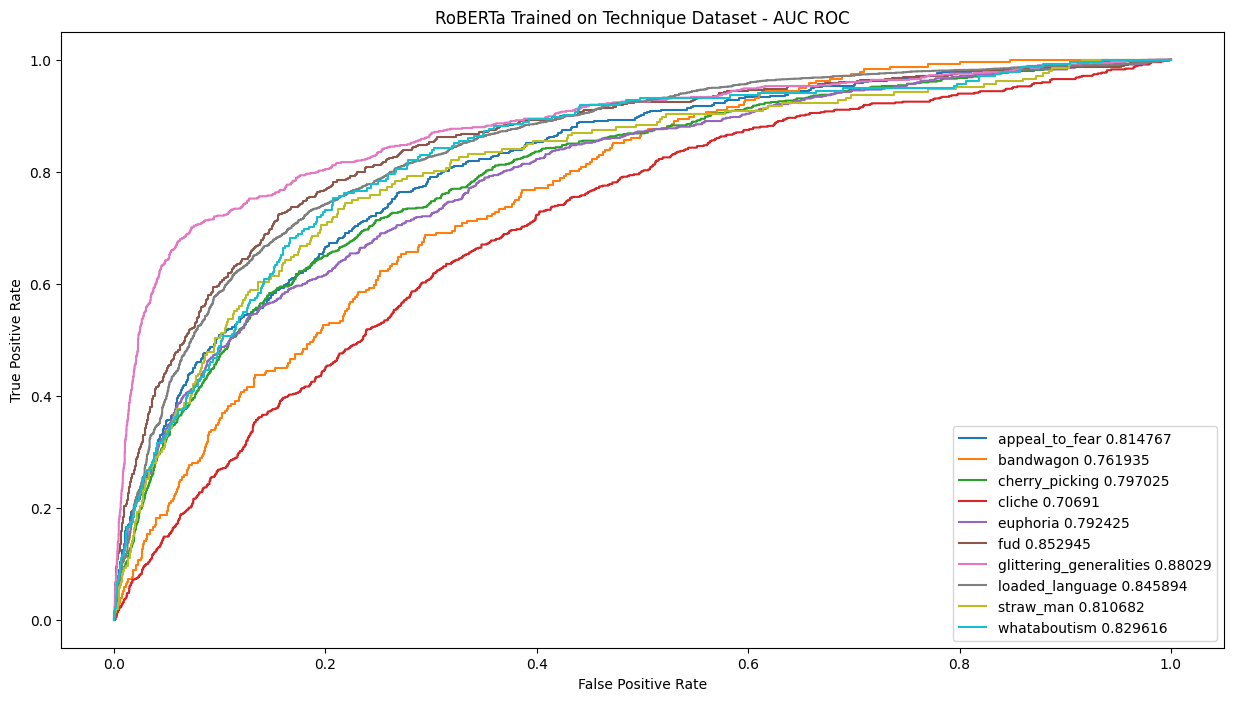

In [75]:
from sklearn import metrics
plt.figure(figsize=(15, 8))
for i, attribute in enumerate(mlb.classes_):
  fpr, tpr, _ = metrics.roc_curve(
      y_final_test.iloc[:,i].astype(int), test_predictions[:, i])
  auc = metrics.roc_auc_score(
      y_final_test.iloc[:,i].astype(int), test_predictions[:, i])
  plt.plot(fpr, tpr, label='%s %g' % (attribute, auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('RoBERTa Trained on Technique Dataset - AUC ROC')

In [83]:
# Final prediction using best thresholds
y_pred_optimized_test = np.zeros_like(test_predictions, dtype=int)
for i in range(test_predictions.shape[1]):
    y_pred_optimized_test[:, i] = (test_predictions[:, i] >= best_thresholds[i]).astype(int)

# Evaluate
from sklearn.metrics import classification_report
print("Classification Report with Optimized Thresholds:\n")
print(classification_report(y_final_test, y_pred_optimized_test, target_names=mlb.classes_))

Classification Report with Optimized Thresholds:

                         precision    recall  f1-score   support

         appeal_to_fear       0.34      0.44      0.39       449
              bandwagon       0.14      0.25      0.18       236
         cherry_picking       0.41      0.51      0.45       768
                 cliche       0.27      0.35      0.30       694
               euphoria       0.41      0.47      0.44       694
                    fud       0.48      0.48      0.48       576
glittering_generalities       0.68      0.62      0.65       722
        loaded_language       0.81      0.73      0.77      2954
              straw_man       0.23      0.27      0.25       207
           whataboutism       0.25      0.31      0.27       235

              micro avg       0.52      0.56      0.54      7535
              macro avg       0.40      0.44      0.42      7535
           weighted avg       0.56      0.56      0.56      7535
            samples avg       0.38    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
